### Importing necessary libraries and datasets

In [1]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import ast

In [2]:
new_df = pd.read_csv('A:/CODES/PROJECTS/appartments/models/data_viz1.csv')
df = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_missing_value_imputation.csv')
df1 = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties.csv')
# This data contains the average of price_per_sqft, price, built_up_area column for a sector and it's latitude and longitude.

In [3]:
group_df = new_df.groupby('sector').mean(numeric_only=True)[['price','price_per_sqft','built_up_area','latitude','longitude']]

In [4]:
group_df
# This data contains the average of price_per_sqft, price, built_up_area column for a sector and it's latitude and longitude.

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
...,...,...,...,...,...
sector 91,1.648235,7586.117647,2028.647059,28.4014,76.9225
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326


In [ ]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

wordcloud_df.head()

,features,sector
0,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sohna road
1,"['Centrally Air Conditioned', 'Water purifier'...",sector 72
2,NaN,sector 12
3,['Private Garden / Terrace'],sector 90
4,"['Centrally Air Conditioned', 'Water purifier'...",sector 49


In [ ]:
main = []

for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

feature_text = ' '.join(main)

In [9]:
pickle.dump(feature_text, open('A:/CODES/PROJECTS/appartments/models/feature_text.pkl','wb'))

### Graph 1

In [10]:
# we can also use choropleth map if we have the shape of each sector.
fig = px.scatter_map(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  map_style="open-street-map", text=group_df.index)
fig.show()

### Graph 2

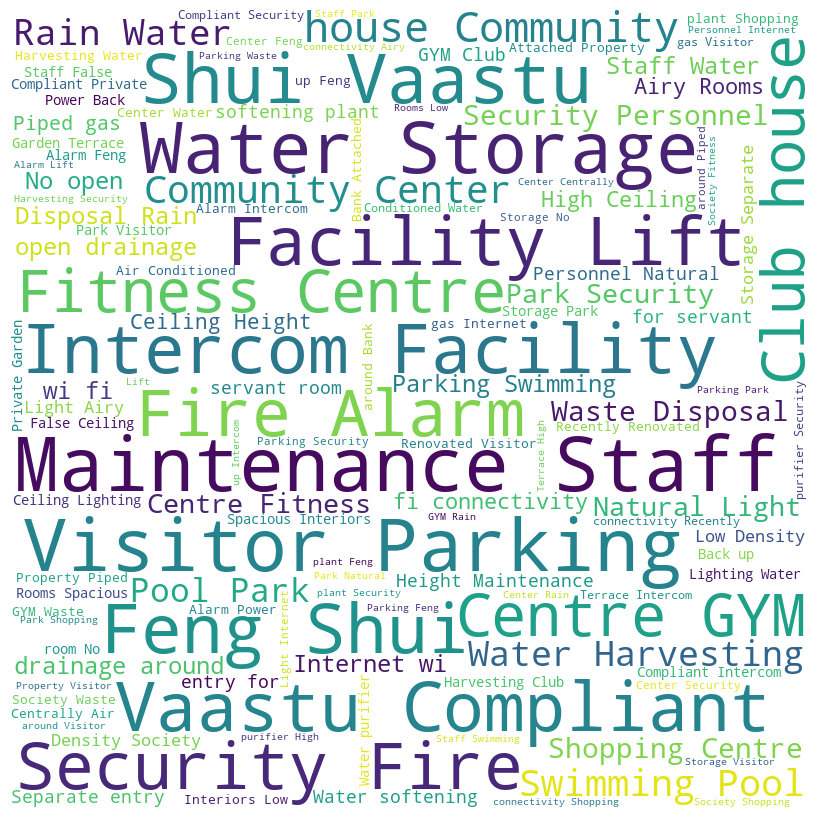

In [11]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

### Graph 3

In [12]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

### Graph 4

In [13]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

### Graph 5

In [14]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')
fig.show()

### Graph 6

(-5.0, 35.0)

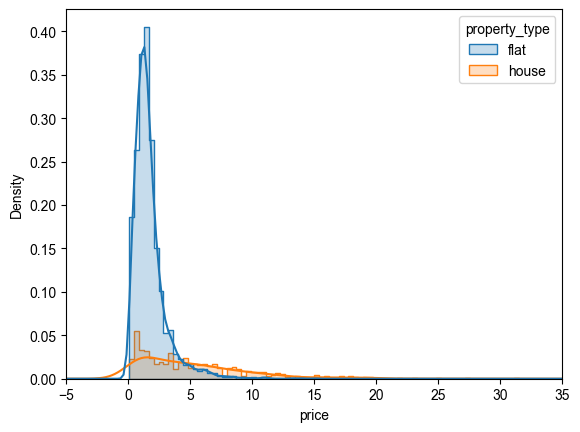

In [15]:
# sns.distplot(df[df['property_type'] == 'house']['price'])
# sns.distplot(df[df['property_type'] == 'flat']['price'])
sns.histplot(data=df[df['property_type'].isin(['flat', 'house'])], x='price', hue='property_type', kde=True, bins=80, element='step',
    stat='density', kde_kws={'cut': 15})
plt.xlim(-5, 35)